In [1]:
list.of.packages <- c("tidyverse","data.table","stargazer","terra","curl","viridis","sf","ggpubr")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=1200, message=FALSE, warning=TRUE)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objets suivants sont masqués depuis ‘package:dplyr’:

    between, first, last


L'objet suivant est masqué depuis ‘package:purrr’:

    transpose



Please cite as: 


 Hlavac, Marek (2022).

# India shp

In [2]:
path_shp_india <- "./0_input/districts_borders/Census_2001/IND_adm0.shp"
india <- st_read(path_shp_india)

Reading layer `IND_adm0' from data source 
  `/diskdata/cired/lepault/V6_Heat_India_30_20_10/0_input/districts_borders/Census_2001/IND_adm0.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1 feature and 70 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 68.18625 ymin: 6.754256 xmax: 97.41516 ymax: 35.50133
Geodetic CRS:  WGS 84


In [3]:
theme_map <- function(...) {
  # On part du theme minimal, qui existe déjà
  # on retire juste les axes
  theme(
    title = element_text(size = 24),
    axis.line = element_blank(),
    axis.ticks = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 16),
    legend.key.size = unit(2, "cm"),
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    panel.background = element_rect(fill = "aliceblue"),
  )
}

# Children

In [4]:
r_child <- rast("./0_input/WorldPop/output/children/summed_children.tiff")
r_child

class       : SpatRaster 
size        : 345, 351, 1  (nrow, ncol, nlyr)
resolution  : 0.08333333, 0.08333333  (x, y)
extent      : 68.18542, 97.43542, 6.75125, 35.50125  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : summed_children.tiff 
name        :          sum 
min value   : 3.865541e-02 
max value   : 2.368818e+05 

In [5]:
total_children <- global(r_child, fun = "sum", na.rm = TRUE)
total_children

,sum
,<dbl>
sum,123228486


In [6]:
total_children/10^6

,sum
,<dbl>
sum,123.2285


In [7]:
df_child <- as.data.frame(r_child, xy = TRUE)%>%
                    mutate(pop = ifelse(sum<10*10^3,"(0,10(",
                                             ifelse(sum>=10*10^3 & sum<50*10^3,"(10,50(",
                                               ifelse(sum>=50*10^3 & sum<10^5,"(50,100(",">100"))))

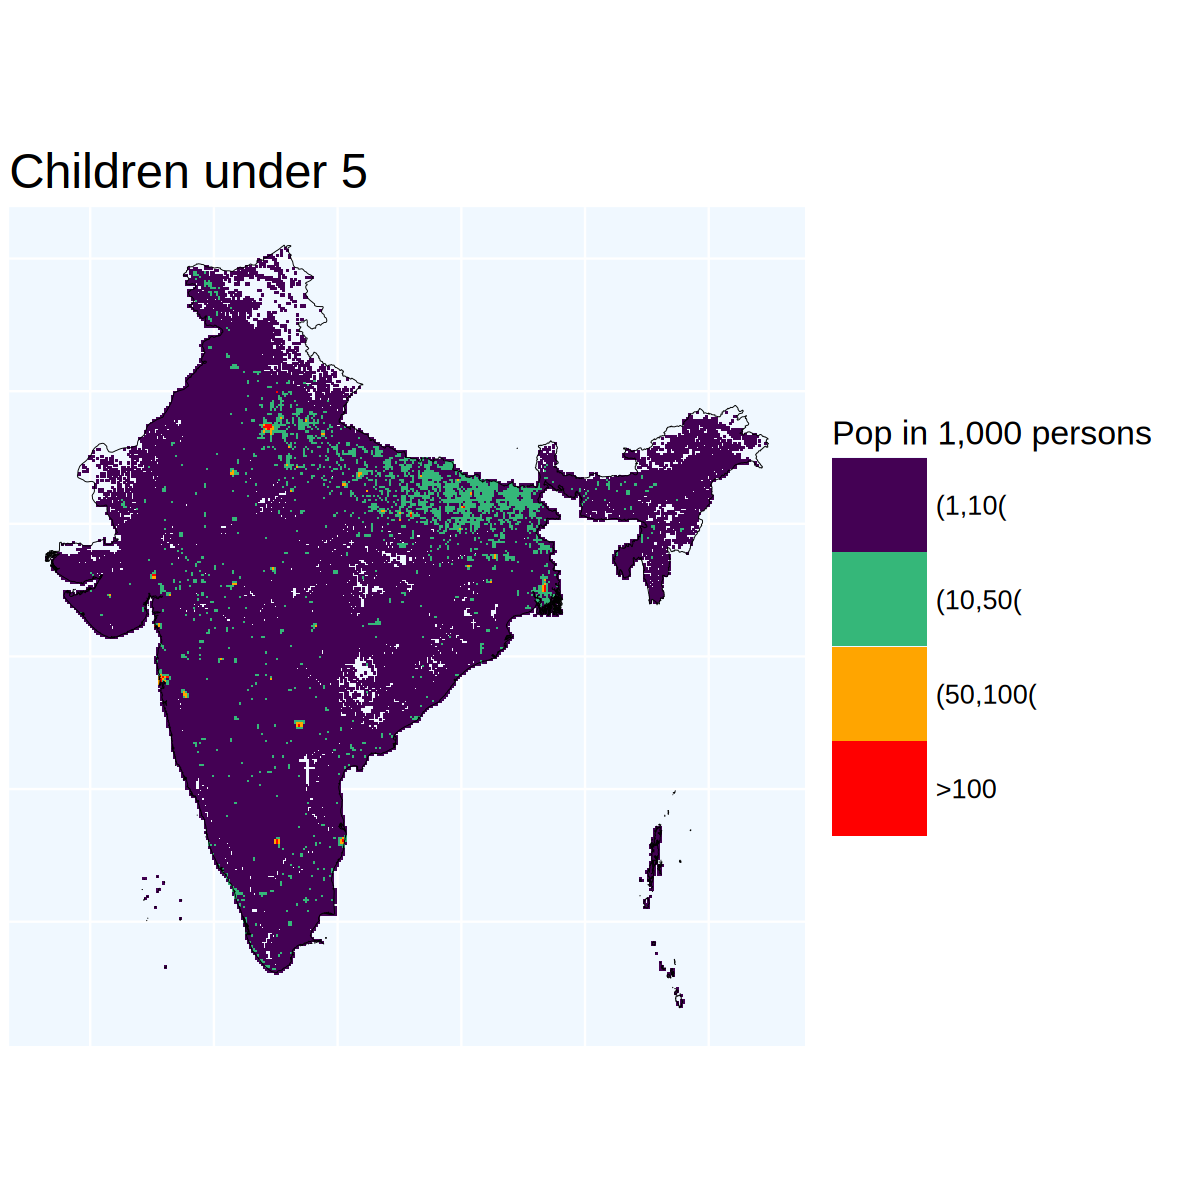

In [8]:
options(repr.plot.width=10, repr.plot.height=10)

map_children <- ggplot() +
                    geom_tile(data = df_child, aes(x = x, y = y, fill = pop)) +
                    geom_sf(data = india, fill=NA, color="black", lwd=0.2, alpha=0.9)+
                    scale_fill_manual(values = c('#440154FF','#35B779FF','orange','red'),#3 of viridis(4),
                                          na.value="white",
                                          labels=c("(1,10(","(10,50(","(50,100(",">100"))+
                    labs(title= "Children under 5", fill = "Pop in 1,000 persons") +
                    theme_map()
map_children

# Women

In [9]:
r_women <- rast("./0_input/WorldPop/output/women/summed_women.tiff")
r_women

class       : SpatRaster 
size        : 345, 351, 1  (nrow, ncol, nlyr)
resolution  : 0.08333333, 0.08333333  (x, y)
extent      : 68.18542, 97.43542, 6.75125, 35.50125  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : summed_women.tiff 
name        :          sum 
min value   : 1.518113e-01 
max value   : 1.092190e+06 

In [10]:
total_women <- global(r_women, fun = "sum", na.rm = TRUE)
total_women

,sum
,<dbl>
sum,338576466


### [OMS](https://platform.who.int/data/maternal-newborn-child-adolescent-ageing/indicator-explorer-new/mca/women-of-reproductive-age-(15-49-years)-population-(thousands))  367*10^6 

In [11]:
total_women/10^6

,sum
,<dbl>
sum,338.5765


In [12]:
df_women <- as.data.frame(r_women, xy = TRUE)%>%
                    mutate(pop = ifelse(sum<10*10^3,"(0,10(",
                                             ifelse(sum>=10*10^3 & sum<50*10^3,"(10,50(",
                                               ifelse(sum>=50*10^3 & sum<10^5,"(50,100(",">100"))))
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "37343 rows x 4 columns"

,x,y,sum,pop
,<dbl>,<dbl>,<dbl>,<chr>
468,77.89375,35.37625,12.219054,"(0,10("
817,77.72708,35.29292,5.157234,"(0,10("


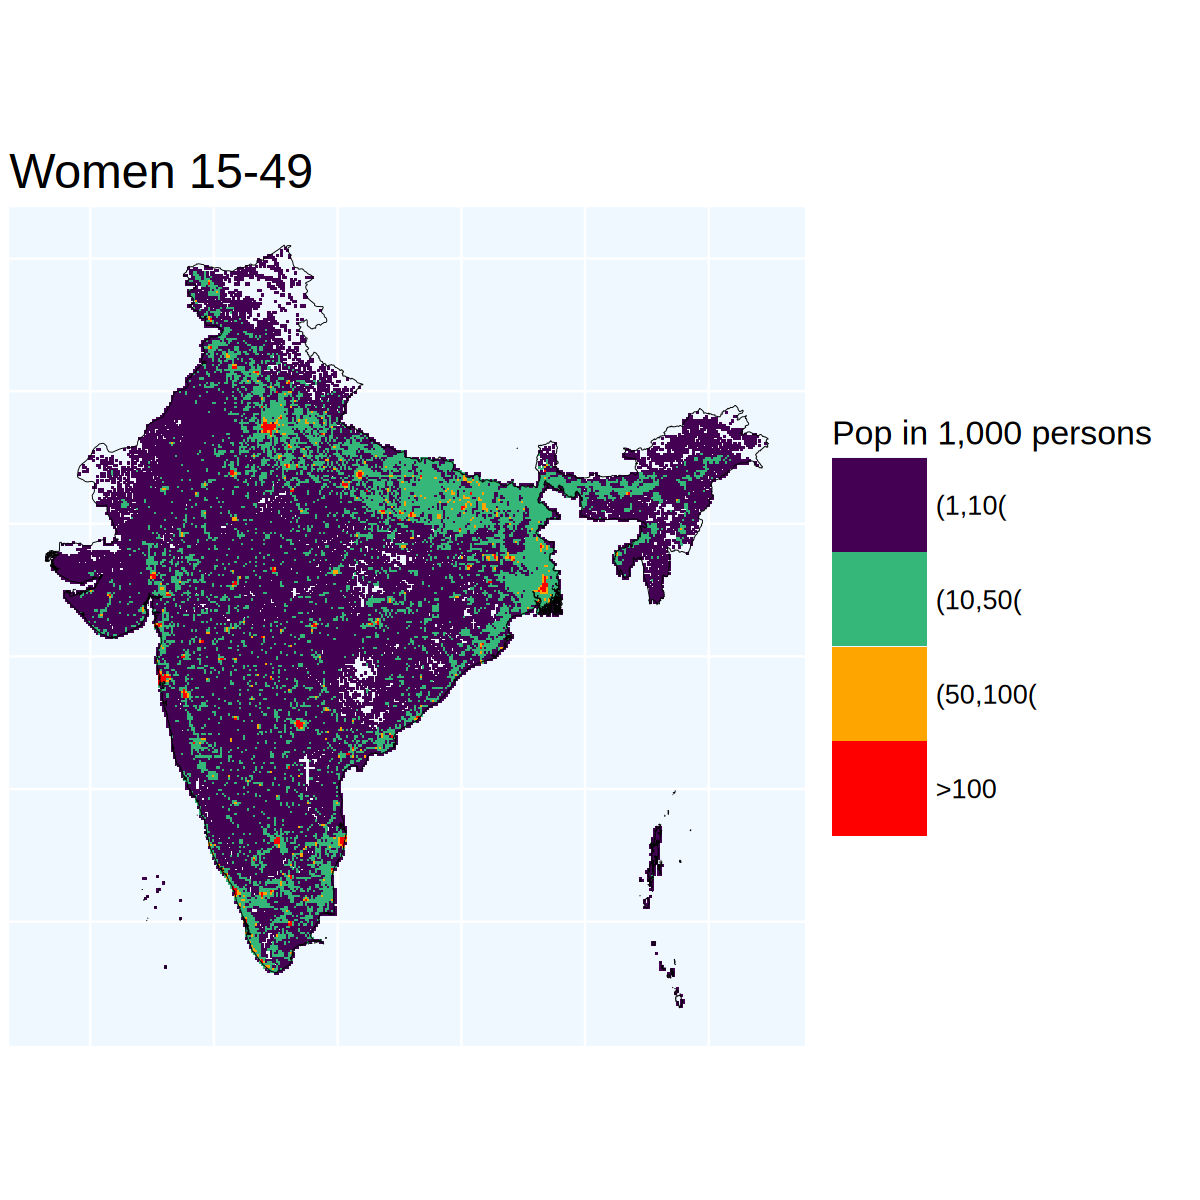

In [13]:
options(repr.plot.width=10, repr.plot.height=10)

map_women <- ggplot() +
                    geom_tile(data = df_women, aes(x = x, y = y, fill = pop)) +
                    geom_sf(data = india, fill=NA, color="black", lwd=0.2, alpha=0.9)+
                    scale_fill_manual(values = c('#440154FF','#35B779FF','orange','red'),#3 of viridis(4),
                                          na.value="white",
                                          labels=c("(1,10(","(10,50(","(50,100(",">100"))+
                    labs(title= "Women 15-49", fill = "Pop in 1,000 persons") +
                    theme_map()
map_women

# Men

In [14]:
r_men <- rast("./0_input/WorldPop/output/men/summed_men.tiff")
r_men

class       : SpatRaster 
size        : 345, 351, 1  (nrow, ncol, nlyr)
resolution  : 0.08333333, 0.08333333  (x, y)
extent      : 68.18542, 97.43542, 6.75125, 35.50125  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : summed_men.tiff 
name        :          sum 
min value   : 2.044207e-01 
max value   : 1.346191e+06 

In [15]:
total_men <- global(r_men, fun = "sum", na.rm = TRUE)
total_men

,sum
,<dbl>
sum,394356184


In [16]:
df_men <- as.data.frame(r_men, xy = TRUE)%>%
                    mutate(pop = ifelse(sum<10*10^3,"(0,10(",
                                             ifelse(sum>=10*10^3 & sum<50*10^3,"(10,50(",
                                               ifelse(sum>=50*10^3 & sum<10^5,"(50,100(",">100"))))

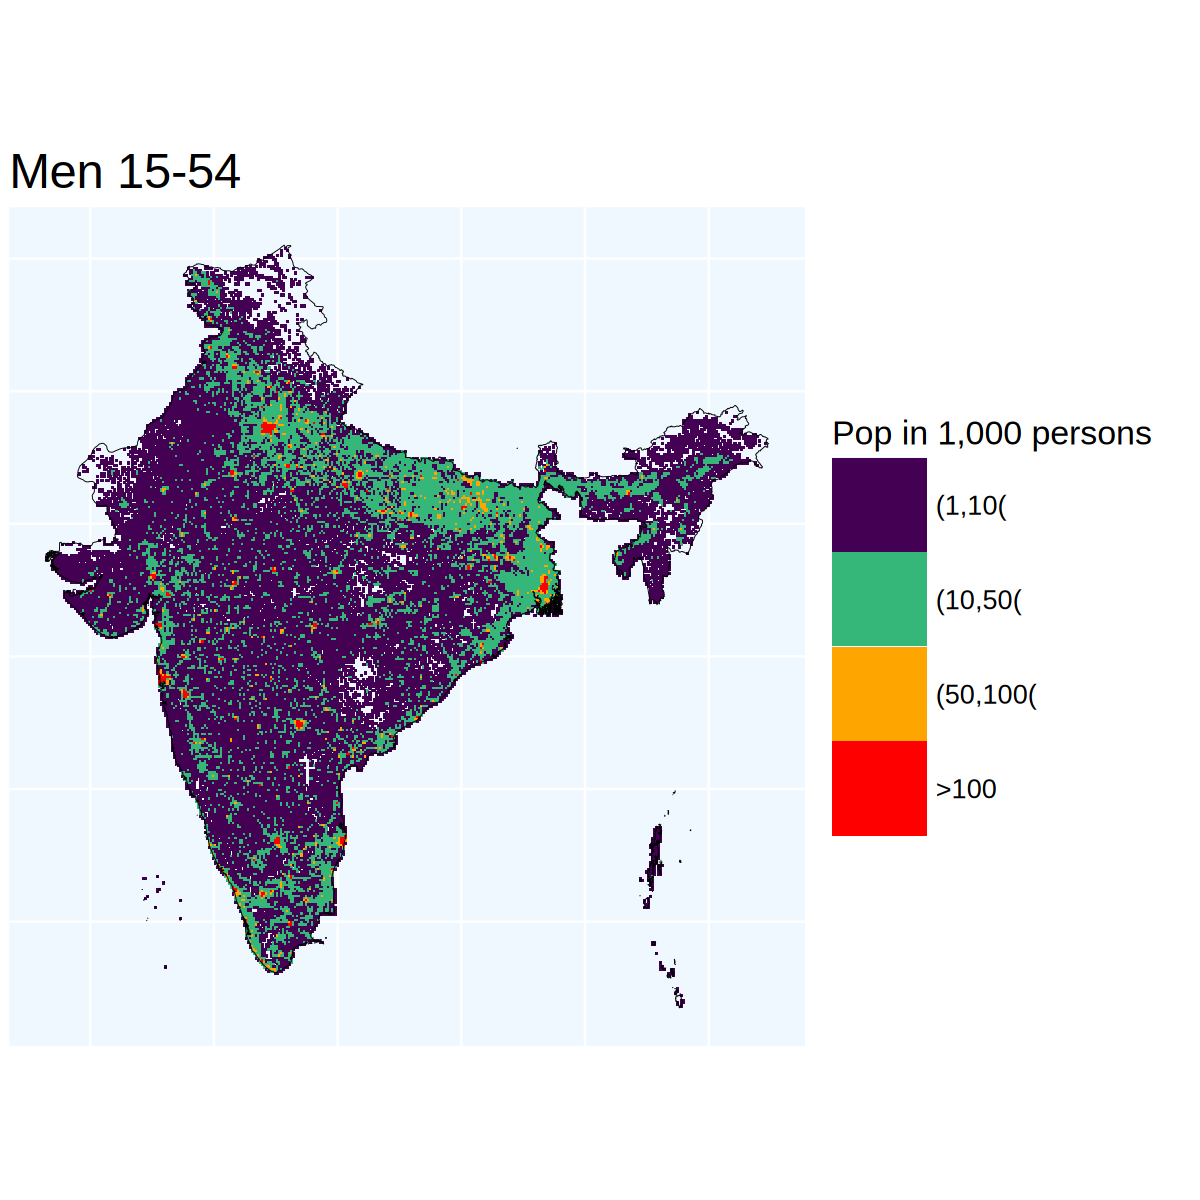

In [17]:
options(repr.plot.width=10, repr.plot.height=10)

map_men <- ggplot() +
                    geom_tile(data = df_men, aes(x = x, y = y, fill = pop)) +
                    geom_sf(data = india, fill=NA, color="black", lwd=0.2, alpha=0.9)+
                    scale_fill_manual(values = c('#440154FF','#35B779FF','orange','red'),#3 of viridis(4),
                                      na.value="white",
                                      labels=c("(1,10(","(10,50(","(50,100(",">100"))+
                    labs(title= "Men 15-54", fill = "Pop in 1,000 persons") +
                    theme_map()
map_men

# Maps 

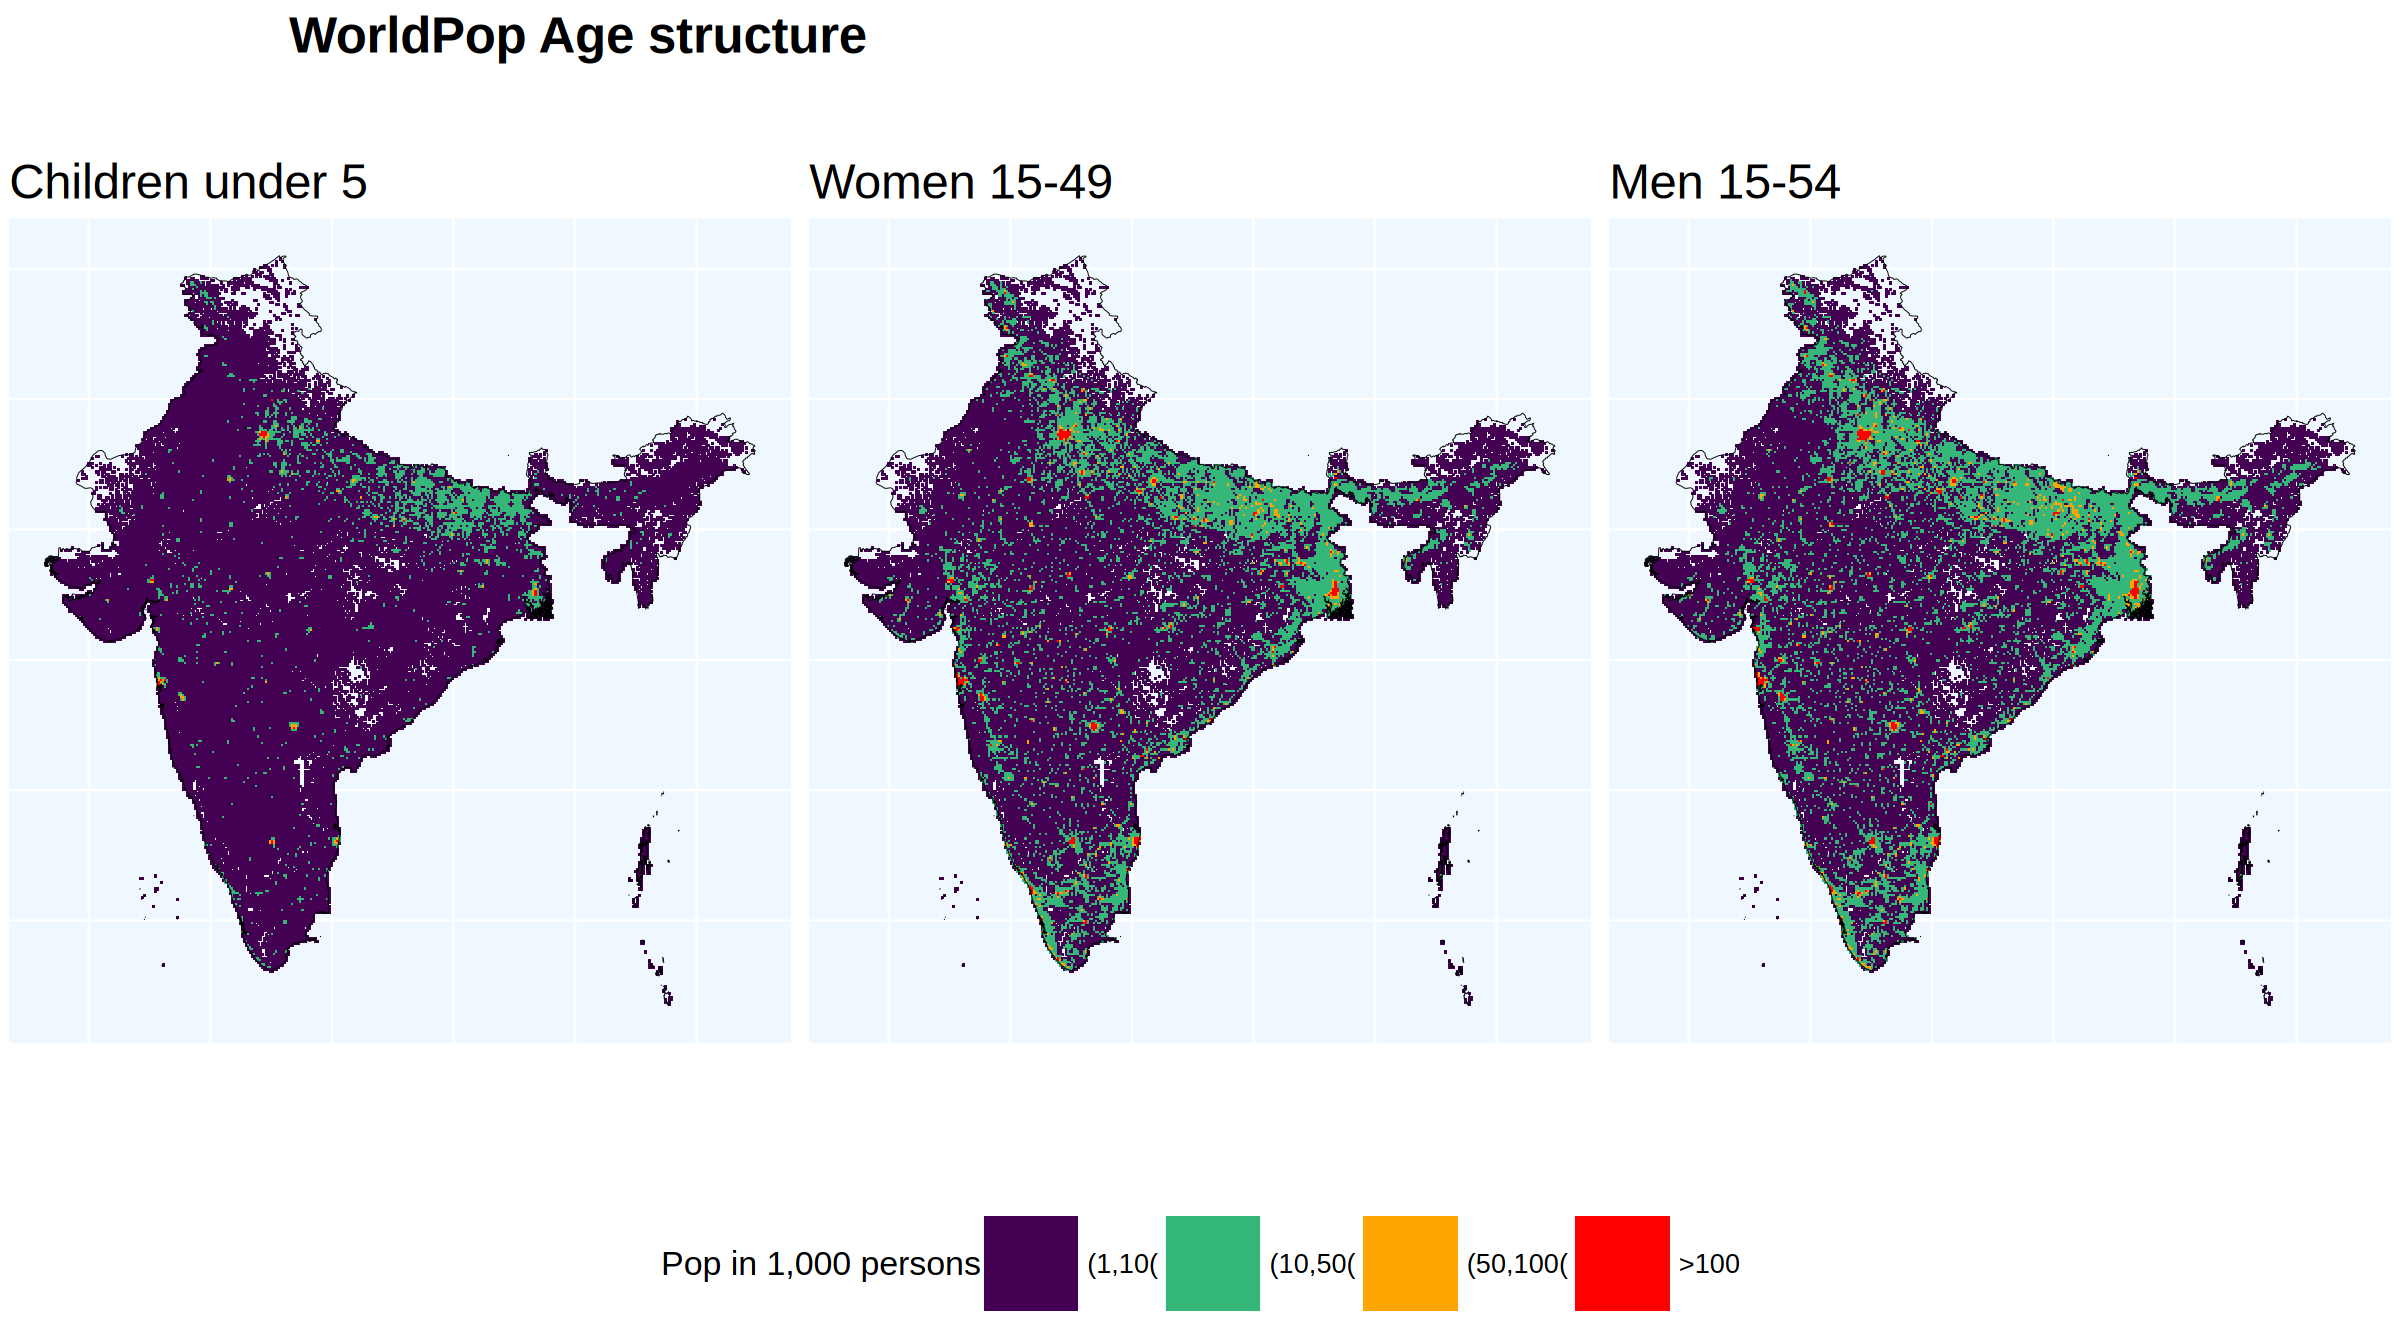

In [18]:
options(repr.plot.width=20, repr.plot.height=11, scipen=9999)

plot_maps_DHS <- ggarrange(map_children, map_women, map_men,
                           labels = c("WorldPop Age structure", "",""),
                           font.label = list(size = 30),
                           common.legend = TRUE, legend = "bottom", ncol=3, nrow = 1)
plot_maps_DHS

In [19]:
ggsave("./3_output/img/maps_pop.png", width=20, height=11, plot_maps_DHS)